In [ ]:
%pip install -q "transformers>=4.55" "huggingface_hub>=0.27" "accelerate>=1.2" "safetensors>=0.4" "scikit-learn>=1.4" "seaborn>=0.13" pandas matplotlib joblib

In [ ]:
import json
import joblib
import platform
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import transformers
from huggingface_hub import login
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoModelForCausalLM, AutoTokenizer
from google.colab import files

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 100)

print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "sklearn": sklearn.__version__,
    "cuda": torch.cuda.is_available(),
})

{'python': '3.13.15', 'torch': '2.11.0+cpu', 'transformers': '5.16.1', 'sklearn': '1.6.1', 'cuda': False}


In [ ]:
import os

# Uncomment only if your environment is not already authenticated.
#note you have to create an account at higgsfield and accept the terms of use for gemma
#os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN
# login()  # prompts securely; do not write the token in source code

MODEL_ID = "google/gemma-2-2b"
# MODEL_ID = "google/gemma-3-270m-it"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("cpu")
DTYPE = torch.bfloat16 if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "right"  # required by our last-token pooling calculation
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=DTYPE,
        low_cpu_mem_usage=True,
    )
    model.to(DEVICE).eval()
    model.requires_grad_(False)  # make the frozen-model contract explicit

    n_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Loaded: {MODEL_ID}")
    print(f"Device: {DEVICE} | dtype: {DTYPE}")
    print(f"Parameters: {n_params / 1e6:,.1f}M | currently marked trainable: {trainable_params / 1e6:,.1f}M")
except OSError as e:
    print(f"Error loading model: {e}")
    print("\nThis usually means you need to accept the Gemma model's terms and provide a Hugging Face token.")
    print("1. Go to https://huggingface.co/google/gemma-3-270m-it and accept the terms.")
    print("2. Create a read token at https://huggingface.co/settings/tokens.")
    print("3. In Colab, add the token to the secrets manager (🔑 icon on the left panel) as `HF_TOKEN` or set it in the environment variable `HF_TOKEN`.")
    print("   Alternatively, uncomment and run `login()` in a new cell to authenticate interactively (do not hardcode the token in your notebook).")
    model = None # Ensure model is None if loading fails

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Loaded: google/gemma-2-2b
Device: cpu | dtype: torch.float32
Parameters: 2,614.3M | currently marked trainable: 0.0M


In [ ]:
# messages = [{"role": "user", "content": "Explain a Transformer hidden state in two short sentences."}]
# chat_inputs = tokenizer.apply_chat_template(
#     messages,
#     add_generation_prompt=True,
#     tokenize=True,
#     return_dict=True,
#     return_tensors="pt",
# ).to(DEVICE)

# with torch.inference_mode():
#     generated = model.generate(
#         **chat_inputs,
#         max_new_tokens=60,
#         do_sample=False,
#         pad_token_id=tokenizer.pad_token_id,
#     )

# new_tokens = generated[0, chat_inputs["input_ids"].shape[1]:]
# print(tokenizer.decode(new_tokens, skip_special_tokens=True))

# print(tokenizer.chat_template)
# print(tokenizer.name_or_path)

prompt = "Explain a Transformer hidden state in two short sentences."

inputs = tokenizer(
    prompt,
    return_tensors="pt",
).to(DEVICE)

with torch.inference_mode():
    generated = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

new_tokens = generated[0, inputs["input_ids"].shape[1]:]
print(tokenizer.decode(new_tokens, skip_special_tokens=True))



A transformer has 80 loops in the primary coil and 40 loops in the secondary


In [ ]:
architecture = {
    "model_type": model.config.model_type,
    "layers": model.config.num_hidden_layers,
    "hidden_size": model.config.hidden_size,
    "attention_heads": model.config.num_attention_heads,
    "kv_heads": getattr(model.config, "num_key_value_heads", None),
    "vocab_size": model.config.vocab_size,
    "max_positions": getattr(model.config, "max_position_embeddings", None),
}

pd.Series(architecture, name="value").to_frame()

,value
model_type,gemma2
layers,26
hidden_size,2304
attention_heads,8
kv_heads,4
vocab_size,256000
max_positions,8192


In [ ]:
# train_toxic = [
#     "You are completely useless and nobody wants your help.",
#     "Shut up, you pathetic fool.",
#     "I will make you regret saying that.",
#     "What an idiot; leave this group.",
#     "People like you ruin everything.",
#     "You are disgusting and should disappear.",
#     "This is garbage, just like all your work.",
#     "I hate you. Get lost.",
#     "You are too stupid to understand anything.",
#     "I hope you fail and everyone laughs at you.",
#     "You deserve to be humiliated.",
#     "Nobody cares about your worthless opinion.",
#     "Go away; your presence makes everything worse.",
#     "I will ruin your reputation for this.",
#     "You are an embarrassment to the whole team.",
#     "Stop talking, moron.",
# ]

# train_nontoxic = [
#     "I disagree, but I appreciate your perspective.",
#     "This draft needs revision before we publish it.",
#     "Could you explain how you reached that conclusion?",
#     "I am frustrated by the delay, so let us reset the timeline.",
#     "The calculation is incorrect; the second term needs a minus sign.",
#     "Thank you for taking the time to review this.",
#     "Please stop the deployment until the tests pass.",
#     "The proposal does not meet the stated requirements.",
#     "I would prefer a different approach to this problem.",
#     "Your presentation was clear and useful.",
#     "Let us discuss the disagreement calmly tomorrow.",
#     "The service failed again, and we need to investigate why.",
#     "I cannot approve this version because evidence is missing.",
#     "We should invite another reviewer to reduce bias.",
#     "That comment surprised me; can you clarify it?",
#     "I value your help even though we reached different answers.",
# ]

# test_toxic = [
#     "Your ideas are worthless, so keep quiet.",
#     "Everyone would be better off without you here.",
#     "I am going to make your life miserable.",
#     "Only a fool could produce work this bad.",
#     "You are a disgrace and should leave.",
#     "No one asked for your stupid opinion.",
#     "I cannot stand you; just disappear.",
#     "You will pay for embarrassing me.",
# ]

# test_nontoxic = [
#     "I strongly oppose this decision, but I respect the committee.",
#     "Please remove this section because its evidence is weak.",
#     "The result is disappointing; let us diagnose the failure.",
#     "Could we pause and return to the original question?",
#     "I do not think this method is reliable yet.",
#     "Your answer contains an error in the final step.",
#     "We need a safer plan before continuing.",
#     "Thanks for the attempt; a second draft would help.",
# ]

# def rows(texts, label, split):
#     return [{"text": text, "label": label, "split": split} for text in texts]

# df = pd.DataFrame(
#     rows(train_toxic, 1, "train")
#     + rows(train_nontoxic, 0, "train")
#     + rows(test_toxic, 1, "test")
#     + rows(test_nontoxic, 0, "test")
# )
# df["label_name"] = df["label"].map({0: "non-toxic", 1: "toxic"})
# display(df.sample(8, random_state=SEED))
# display(pd.crosstab(df["split"], df["label_name"], margins=True))

# from datasets import load_dataset
# import pandas as pd

# dataset = load_dataset("google/civil_comments")

# train_raw = dataset["train"].to_pandas()
# test_raw = dataset["test"].to_pandas()

# SEED = 17

# # Start with a manageable benchmark size
# train_raw = train_raw.sample(
#     n=5000,
#     random_state=SEED
# )

# test_raw = test_raw.sample(
#     n=1000,
#     random_state=SEED
# )

# train_raw["split"] = "train"
# test_raw["split"] = "test"

# df = pd.concat(
#     [train_raw, test_raw],
#     ignore_index=True
# )

# # Convert continuous toxicity annotation to binary label
# df["label"] = (df["toxicity"] >= 0.5).astype(int)

# df["label_name"] = df["label"].map({
#     0: "non-toxic",
#     1: "toxic"
# })

# df = df[[
#     "text",
#     "label",
#     "label_name",
#     "split",
#     "toxicity"
# ]]

# # # Save representations
# # np.save("gemma_representations.npy", representations)

# # # Download to your computer
# # files.download("gemma_representations.npy")

# # display(df.head(n=20))
# display(df.sample(20, random_state=SEED))
# display(pd.crosstab(df["split"], df["label_name"], margins=True))

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("google/civil_comments")

train_raw = dataset["train"].to_pandas()
test_raw = dataset["test"].to_pandas()

SEED = 34

# Convert toxicity score to binary label first
train_raw["label"] = (train_raw["toxicity"] >= 0.5).astype(int)
test_raw["label"] = (test_raw["toxicity"] >= 0.5).astype(int)

# -----------------------------
# Balanced training set: 50:50
# -----------------------------

train_toxic = train_raw[train_raw["label"] == 1]
train_nontoxic = train_raw[train_raw["label"] == 0]

n_train = 10

train_toxic = train_toxic.sample(
    n=n_train,
    random_state=SEED
)

train_nontoxic = train_nontoxic.sample(
    n=n_train,
    random_state=SEED
)

train_raw = pd.concat(
    [train_toxic, train_nontoxic],
    ignore_index=True
)

# -----------------------------
# Balanced test set: 50:50
# -----------------------------

test_toxic = test_raw[test_raw["label"] == 1]
test_nontoxic = test_raw[test_raw["label"] == 0]

n_test = 1

test_toxic = test_toxic.sample(
    n=n_test,
    random_state=SEED
)

test_nontoxic = test_nontoxic.sample(
    n=n_test,
    random_state=SEED
)

test_raw = pd.concat(
    [test_toxic, test_nontoxic],
    ignore_index=True
)

# Add split information
train_raw["split"] = "train"
test_raw["split"] = "test"

# Combine
df = pd.concat(
    [train_raw, test_raw],
    ignore_index=True
)

df["label_name"] = df["label"].map({
    0: "non-toxic",
    1: "toxic"
})

df = df[[
    "text",
    "label",
    "label_name",
    "split",
    "toxicity"
]]

# Shuffle rows
df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

display(df.sample(20, random_state=SEED))
display(
    pd.crosstab(
        df["split"],
        df["label_name"],
        margins=True
    )
)

README.md:   0%|          | 0.00/7.73k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  194MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  187MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

,text,label,label_name,split,toxicity
17,WTF is wrong with you people? Confederate flags in this era stand for one thing and if you are g...,1,toxic,train,0.587500
7,"Well, then, forget it.",0,non-toxic,train,0.000000
21,"This is very foolish given the Americans will move away from climate change legislation, it is d...",1,toxic,train,0.500000
12,"So the TDS addled Left is still going with that one?\n\nYeah, Trump is such an ""idiot"" that desp...",1,toxic,train,0.854545
0,">>"" ... it’s been quite the ride for me, """"\n\nPretty smooth actually - safe, bland, predictably...",0,non-toxic,train,0.000000
14,"""They talk about solidarity and the inclusion of people who are brown and black, Muslim, native,...",1,toxic,test,0.800000
18,"They are equally sick of the ugly ""pants suit"" liar!",1,toxic,train,0.796610
15,This is not connected with the situation the state is in? The more spotlight you put on it the w...,0,non-toxic,train,0.000000
16,"Don't get too carried away, Kearon, with your radical assumptions. Apparently there's reports t...",1,toxic,train,0.600000
6,In two weeks I have seen two different bikes riding in the road the wrong way on a one-way (C st...,0,non-toxic,train,0.000000


label_name,non-toxic,toxic,All
split,,,
test,1,1,2
train,10,10,20
All,11,11,22


In [ ]:
def extract_last_token_representations(texts, batch_size=8, max_length=260):
    """Return [n_examples, n_hidden_state_points, hidden_size] float32 NumPy array."""
    batches = []
    for start in range(0, len(texts), batch_size):
        text_batch = texts[start:start + batch_size]
        encoded = tokenizer(
            text_batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(DEVICE)

        with torch.inference_mode():
            output = model(
                **encoded,
                output_hidden_states=True,
                use_cache=False,
                return_dict=True,
            )

        last_position = encoded["attention_mask"].sum(dim=1) - 1
        batch_index = torch.arange(len(text_batch), device=DEVICE)
        pooled_by_layer = torch.stack(
            [state[batch_index, last_position] for state in output.hidden_states],
            dim=1,
        )
        batches.append(pooled_by_layer.float().cpu().numpy())

    return np.concatenate(batches, axis=0)

representations = extract_last_token_representations(df["text"].tolist())
expected_shape = (len(df), model.config.num_hidden_layers + 1, model.config.hidden_size)
assert representations.shape == expected_shape, (representations.shape, expected_shape)
assert np.isfinite(representations).all()

print("Representation tensor:", representations.shape)
print("Approximate cached size: %.1f MB" % (representations.nbytes / 2**20))
np.save("gemma_representations_balanced.npy", representations)

df.to_csv("representation_metadata_balanced.csv", index=False)

files.download("gemma_representations_balanced.npy")
files.download("representation_metadata_balanced.csv")

Representation tensor: (22, 27, 2304)
Approximate cached size: 5.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

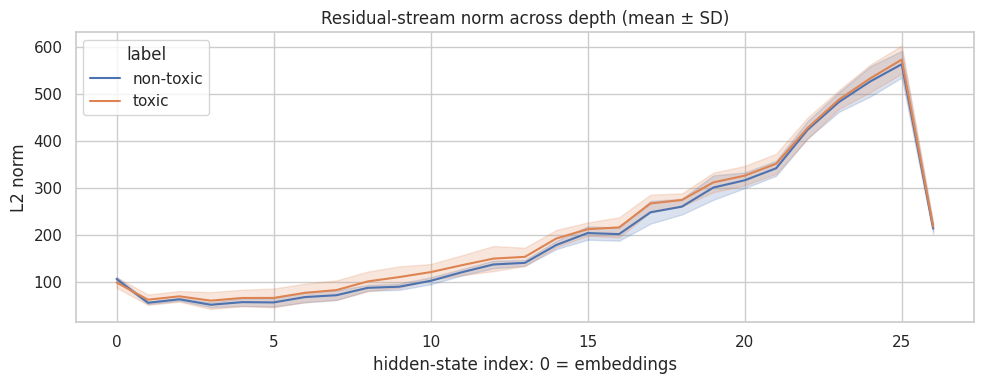

In [ ]:
# Visualize how representation norm evolves with depth.
norms = np.linalg.norm(representations, axis=-1)
norm_df = pd.DataFrame({
    "layer": np.tile(np.arange(norms.shape[1]), len(df)),
    "L2 norm": norms.ravel(),
    "label": np.repeat(df["label_name"].to_numpy(), norms.shape[1]),
})
plt.figure(figsize=(10, 4))
sns.lineplot(data=norm_df, x="layer", y="L2 norm", hue="label", estimator="mean", errorbar="sd")
plt.title("Residual-stream norm across depth (mean ± SD)")
plt.xlabel("hidden-state index: 0 = embeddings")
plt.tight_layout()
plt.savefig(
    "residual-stream-balanced.png",
    dpi=300,
    bbox_inches="tight"
)
files.download("residual-stream-balanced.png")
plt.show()

In [ ]:
train_mask = df["split"].eq("train").to_numpy()
test_mask = df["split"].eq("test").to_numpy()
y_train = df.loc[train_mask, "label"].to_numpy()
y_test = df.loc[test_mask, "label"].to_numpy()

def make_probe():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.03, penalty="l2", max_iter=4000, random_state=SEED),
    )

dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y_train), 1)), y_train)
dummy_accuracy = accuracy_score(y_test, dummy.predict(np.zeros((len(y_test), 1))))

rng = np.random.default_rng(SEED)
layer_rows = []
probes = {}

for layer in range(representations.shape[1]):
    X_train = representations[train_mask, layer, :]
    X_test = representations[test_mask, layer, :]

    probe = make_probe().fit(X_train, y_train)
    probes[layer] = probe
    probabilities = probe.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    shuffled_aurocs = []
    for _ in range(20):
        shuffled_probe = make_probe().fit(X_train, rng.permutation(y_train))
        shuffled_aurocs.append(roc_auc_score(y_test, shuffled_probe.predict_proba(X_test)[:, 1]))

    layer_rows.append({
        "layer": layer,
        "accuracy": accuracy_score(y_test, predictions),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "auroc": roc_auc_score(y_test, probabilities),
        "shuffle_auroc_mean": np.mean(shuffled_aurocs),
        "shuffle_auroc_sd": np.std(shuffled_aurocs),
        "dummy_accuracy": dummy_accuracy,
    })

layer_metrics = pd.DataFrame(layer_rows)
best_layer = int(layer_metrics.loc[layer_metrics["auroc"].idxmax(), "layer"])

best_probe = probes[best_layer]

joblib.dump(best_probe, "trained_probe.joblib")
files.download("trained_probe.joblib")

print(f"Saved probe for layer {best_layer}")
print("File: trained_probe.joblib")
display(layer_metrics.round(3))
print(f"Illustrative best layer by held-out AUROC: {best_layer}")

# Save results as CSV
layer_metrics.to_csv("layer_metrics_balanced.csv", index=False)
files.download("layer_metrics_balanced.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved probe for layer 0
File: trained_probe.joblib


,layer,accuracy,f1,auroc,shuffle_auroc_mean,shuffle_auroc_sd,dummy_accuracy
0,0,1.0,1.000,1.0,0.25,0.433,0.5
1,1,1.0,1.000,1.0,0.50,0.500,0.5
2,2,0.5,0.000,1.0,0.50,0.500,0.5
3,3,0.5,0.000,1.0,0.60,0.490,0.5
4,4,1.0,1.000,1.0,0.40,0.490,0.5
5,5,1.0,1.000,1.0,0.45,0.497,0.5
6,6,1.0,1.000,1.0,0.50,0.500,0.5
7,7,1.0,1.000,1.0,0.65,0.477,0.5
8,8,0.5,0.000,1.0,0.45,0.497,0.5
9,9,1.0,1.000,1.0,0.40,0.490,0.5


Illustrative best layer by held-out AUROC: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
from competition_probe import fit_competition_ensemble



X_competition = representations[train_mask, best_layer, :]
y_competition = y_train
groups_competition = None
competition_artifact = fit_competition_ensemble(
    X_competition, y_competition, groups=groups_competition, seed=SEED, repeats=10
)
print("Selected probes:", competition_artifact["model_names"])
print("Weights:", np.round(competition_artifact["weights"], 3))
print("OOF multi-metric score:", round(competition_artifact["oof_score"], 4))
print("OOF threshold:", round(competition_artifact["threshold"], 3))

SUBMISSION_DIR = Path("submission_build")
SUBMISSION_DIR.mkdir(exist_ok=True)


submission_probe_path = SUBMISSION_DIR / "trained_probe.joblib"
joblib.dump(competition_artifact, submission_probe_path)


classifier_source = """import numpy as np
import joblib
from pathlib import Path


class Classifier:
    def __init__(self):
        model_path = Path(__file__).with_name("trained_probe.joblib")
        self.artifact = joblib.load(model_path)

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        expected = self.artifact["n_features"]
        if X.ndim != 2 or X.shape[1] != expected:
            raise ValueError(f"Expected [n, {expected}] embeddings; got {X.shape}")
        probability = np.zeros(len(X), dtype=float)
        for weight, model in zip(self.artifact["weights"], self.artifact["models"]):
            if hasattr(model, "predict_proba"):
                model_probability = model.predict_proba(X)[:, 1]
            else:
                score = np.clip(model.decision_function(X), -40, 40)
                model_probability = 1.0 / (1.0 + np.exp(-score))
            probability += weight * model_probability
        return (probability >= self.artifact["threshold"]).astype(int)
"""
(SUBMISSION_DIR / "classifier.py").write_text(classifier_source, encoding="utf-8")


submission_zip = Path("submission.zip")
with zipfile.ZipFile(submission_zip, mode="w", compression=zipfile.ZIP_DEFLATED) as archive:
    archive.write(SUBMISSION_DIR / "classifier.py", arcname="classifier.py")
    archive.write(submission_probe_path, arcname="trained_probe.joblib")

with zipfile.ZipFile(submission_zip, mode="r") as archive:
    files_in_zip = archive.namelist()
    expected_files = ["classifier.py", "trained_probe.joblib"]
    assert files_in_zip == expected_files, f"Unexpected ZIP contents: {files_in_zip}"

print(f"Created: {submission_zip.resolve()}")
print(f"ZIP contents: {files_in_zip}")
print(f"Size: {submission_zip.stat().st_size / 1024:.1f} KiB")

ModuleNotFoundError: No module named 'competition_probe'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(layer_metrics["layer"], layer_metrics["auroc"], marker="o", label="true labels", color="#5b5bd6")
axes[0].plot(layer_metrics["layer"], layer_metrics["shuffle_auroc_mean"], marker=".", label="shuffled labels", color="#9ca3af")
axes[0].fill_between(
    layer_metrics["layer"],
    layer_metrics["shuffle_auroc_mean"] - layer_metrics["shuffle_auroc_sd"],
    layer_metrics["shuffle_auroc_mean"] + layer_metrics["shuffle_auroc_sd"],
    color="#9ca3af", alpha=0.18,
)
axes[0].axhline(0.5, linestyle="--", color="black", linewidth=1, label="chance AUROC")
axes[0].axvline(best_layer, linestyle=":", color="#e76f51", linewidth=2)
axes[0].set(title="Where is toxicity linearly decodable?", xlabel="hidden-state index", ylabel="held-out AUROC", ylim=(0, 1.03))
axes[0].legend(loc="lower right")

axes[1].plot(layer_metrics["layer"], layer_metrics["accuracy"], marker="o", label="accuracy", color="#2a9d8f")
axes[1].plot(layer_metrics["layer"], layer_metrics["f1"], marker="s", label="F1", color="#e76f51")
axes[1].axhline(dummy_accuracy, linestyle="--", color="#6b7280", label="dummy accuracy")
axes[1].set(title="Thresholded performance", xlabel="hidden-state index", ylabel="score", ylim=(0, 1.03))
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    "threshold_performance_balanced.png",
    dpi=300,
    bbox_inches="tight"
)
files.download("threshold_performance_balanced.png")
plt.show()

In [ ]:
best_probe = probes[best_layer]
X_test_best = representations[test_mask, best_layer, :]
test_probability = best_probe.predict_proba(X_test_best)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

prediction_table = df.loc[test_mask, ["text", "label", "label_name"]].copy()
prediction_table["p(toxic)"] = test_probability
prediction_table["predicted"] = np.where(test_prediction == 1, "toxic", "non-toxic")
prediction_table["correct"] = prediction_table["label"].to_numpy() == test_prediction
display(prediction_table.sort_values("p(toxic)", ascending=False).style.format({"p(toxic)": "{:.3f}"}))

print(classification_report(y_test, test_prediction, target_names=["non-toxic", "toxic"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, display_labels=["non-toxic", "toxic"], cmap="Blues")
plt.title(f"Held-out confusion matrix · layer {best_layer}")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

files.download("confusion_matrix.png")

# Save prediction table as CSV
prediction_table.to_csv("prediction_table_balanced.csv", index=False)

# Download it in Google Colab
files.download("prediction_table_balanced.csv")

plt.show()

In [ ]:
X_best_all = representations[:, best_layer, :]
X_scaled_all = StandardScaler().fit_transform(X_best_all)  # visualization only; never used for test metrics
projection = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled_all)
pca_df = pd.DataFrame({
    "PC1": projection[:, 0],
    "PC2": projection[:, 1],
    "label": df["label_name"],
    "split": df["split"],
})

plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2", hue="label", style="split", s=105,
    palette={"non-toxic": "#2a9d8f", "toxic": "#e76f51"},
)
plt.title(f"PCA view of layer {best_layer} representations")
plt.tight_layout()

plt.savefig(
    "pca_layer_balanced.png",
    dpi=300,
    bbox_inches="tight"
)

files.download("pca_layer_balanced.png")

plt.show()